# Survival Analysis: Time-to-Event Modeling

Survival analysis is a branch of statistics and machine learning that models the **time until an event of interest occurs**. It goes by many names depending on the field:

- **Reliability analysis** in engineering (time until a machine fails)
- **Duration analysis** in economics (time until someone finds a job)
- **Event history analysis** in social science
- **Churn modeling** in business (time until a customer leaves)

The defining challenge that sets survival analysis apart from ordinary regression is **censoring**: for many subjects, the event has not yet occurred by the time we collect our data. We do not know *when* they will experience the event, but we do know they have survived at least until the observation cutoff. Discarding these observations would bias results; survival analysis uses them correctly.

**This notebook covers:**
- What censoring is and why it matters
- Kaplan-Meier estimator (non-parametric survival curve)
- Log-rank test for comparing groups
- Cox Proportional Hazards model (semi-parametric)
- Weibull Accelerated Failure Time (AFT) model (parametric)
- Concordance index (C-index) as evaluation metric
- Predicting survival probability for new customers

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from lifelines import KaplanMeierFitter, CoxPHFitter, WeibullAFTFitter
from lifelines.statistics import logrank_test

np.random.seed(42)
print('Libraries loaded successfully.')
print('lifelines version:', __import__('lifelines').__version__)

Libraries loaded successfully.
lifelines version: 0.30.3


## 2. Understanding Censoring

Censoring means the event of interest has **not been observed** for some subjects by the study end date. There are several types:

| Type | Description |
|------|-------------|
| **Right censoring** | Most common. Subject leaves study before event occurs (e.g., still a customer when we pull data). |
| **Left censoring** | Event occurred before observation started. |
| **Interval censoring** | We know the event occurred in a time window but not exactly when. |

**Key insight**: Censored observations are NOT failures. They contribute useful information: we know the subject survived *at least* until their censoring time. Dropping them would systematically underestimate survival.

## 3. Synthetic Churn Dataset

We simulate a SaaS company's customer base. Each customer has:
- `duration`: months as a customer (until churn or data cutoff)
- `churned`: 1 if they churned (event observed), 0 if still active (censored)
- `plan_type`: 'basic' or 'premium'
- `age`: customer age in years
- `monthly_usage`: average monthly feature usage score

In [2]:
N = 500

# Plan type: basic customers churn faster
plan_type = np.random.choice(['basic', 'premium'], size=N, p=[0.55, 0.45])

# Age: older customers tend to be more loyal
age = np.random.normal(35, 10, N).clip(18, 70).astype(int)

# Monthly usage: higher usage -> lower churn
monthly_usage = np.random.exponential(scale=40, size=N).clip(1, 200)

# Simulate time to churn based on features
# Scale parameter increases (longer survival) for premium, older, higher usage
scale = (
    18
    + (plan_type == 'premium') * 12
    + (age - 35) * 0.3
    + monthly_usage * 0.15
)

# True churn time drawn from Weibull distribution
true_churn_time = np.random.weibull(1.5, N) * scale

# Study runs for 36 months; customers joining after month 0 have observation window < 36
observation_window = np.random.uniform(12, 36, N)

# Observed duration is min(true_churn_time, observation_window)
duration = np.minimum(true_churn_time, observation_window)
churned = (true_churn_time <= observation_window).astype(int)

df = pd.DataFrame({
    'duration': duration.round(2),
    'churned': churned,
    'plan_type': plan_type,
    'age': age,
    'monthly_usage': monthly_usage.round(1)
})

print(f'Dataset shape: {df.shape}')
print(f'Churn rate (events observed): {df.churned.mean():.1%}')
print(f'Censored (still active): {(df.churned == 0).mean():.1%}')
print()
df.head(10)

Dataset shape: (500, 5)
Churn rate (events observed): 51.8%
Censored (still active): 48.2%



,duration,churned,plan_type,age,monthly_usage
0,4.27,1,basic,38,12.4
1,31.72,0,premium,53,84.4
2,11.22,1,premium,44,63.9
3,20.59,0,premium,29,43.0
4,23.86,0,basic,26,76.0
5,31.88,0,basic,39,80.8
6,2.35,1,basic,21,49.3
7,16.17,0,premium,53,72.6
8,18.35,1,premium,46,47.8
9,20.64,1,premium,30,45.6


In [3]:
print('Churn by plan type:')
print(df.groupby('plan_type').agg(
    n_customers=('churned', 'count'),
    n_churned=('churned', 'sum'),
    churn_rate=('churned', 'mean'),
    median_duration=('duration', 'median')
).round(3))

print('\nSummary statistics:')
df[['duration', 'age', 'monthly_usage']].describe().round(2)

Churn by plan type:
           n_customers  n_churned  churn_rate  median_duration
plan_type                                                     
basic              272        172       0.632           15.015
premium            228         87       0.382           19.005

Summary statistics:


,duration,age,monthly_usage
count,500.00,500.00,500.00
mean,16.97,34.71,40.70
std,8.38,9.77,39.65
min,0.71,18.00,1.00
25%,11.58,28.00,11.18
50%,16.20,34.00,29.85
75%,22.70,41.00,53.78
max,35.50,65.00,200.00


## 4. Kaplan-Meier Estimator

The **Kaplan-Meier (KM) estimator** is the standard non-parametric method for estimating the survival function from data with censoring.

**Survival function**: S(t) = P(T > t) -- the probability of surviving beyond time t.

The KM formula at each event time t_i:

$$S(t) = \prod_{t_i \leq t} \left(1 - \frac{d_i}{n_i}\right)$$

where:
- d_i = number of events at time t_i
- n_i = number at risk just before t_i (still under observation)

**Censored observations contribute to n_i** (the risk set) up until they are censored, then they drop out.

In [4]:
# Fit overall Kaplan-Meier curve
kmf = KaplanMeierFitter()
kmf.fit(df['duration'], event_observed=df['churned'], label='All Customers')

print('Kaplan-Meier Survival Estimates:')
print(f'  Median survival time: {kmf.median_survival_time_:.1f} months')
print(f'  Survival at 12 months: {kmf.survival_function_at_times(12).values[0]:.3f}')
print(f'  Survival at 24 months: {kmf.survival_function_at_times(24).values[0]:.3f}')
print(f'  Survival at 36 months: {kmf.survival_function_at_times(36).values[0]:.3f}')

Kaplan-Meier Survival Estimates:
  Median survival time: 21.6 months
  Survival at 12 months: 0.734
  Survival at 24 months: 0.455
  Survival at 36 months: 0.307


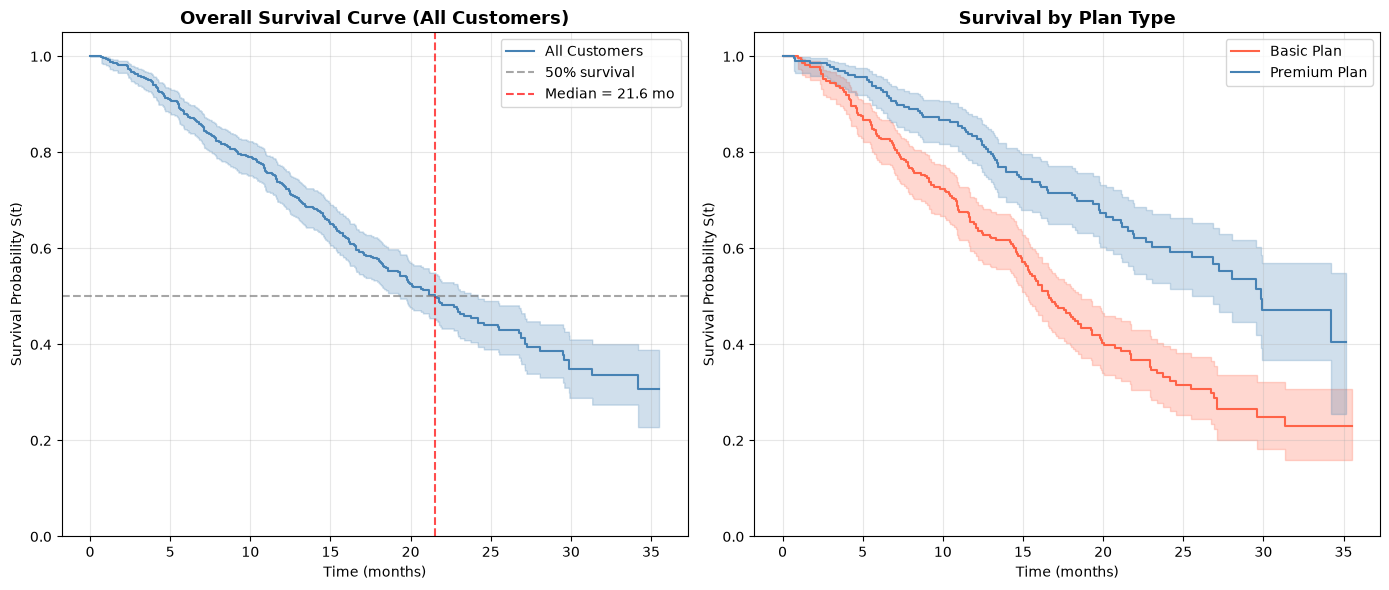

Basic Plan median survival:   16.6 months
Premium Plan median survival: 29.9 months


In [5]:
# Plot overall survival curve with confidence intervals
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: overall curve
ax = axes[0]
kmf.plot_survival_function(ax=ax, ci_show=True, color='steelblue')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='50% survival')
ax.axvline(kmf.median_survival_time_, color='red', linestyle='--', alpha=0.7,
           label=f'Median = {kmf.median_survival_time_:.1f} mo')
ax.set_title('Overall Survival Curve (All Customers)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time (months)')
ax.set_ylabel('Survival Probability S(t)')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)

# Right: stratified by plan type
ax = axes[1]
kmf_basic = KaplanMeierFitter()
kmf_premium = KaplanMeierFitter()

mask_basic = df['plan_type'] == 'basic'
mask_premium = df['plan_type'] == 'premium'

kmf_basic.fit(df.loc[mask_basic, 'duration'],
              event_observed=df.loc[mask_basic, 'churned'],
              label='Basic Plan')
kmf_premium.fit(df.loc[mask_premium, 'duration'],
                event_observed=df.loc[mask_premium, 'churned'],
                label='Premium Plan')

kmf_basic.plot_survival_function(ax=ax, ci_show=True, color='tomato')
kmf_premium.plot_survival_function(ax=ax, ci_show=True, color='steelblue')

ax.set_title('Survival by Plan Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Time (months)')
ax.set_ylabel('Survival Probability S(t)')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('survival_curves.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Basic Plan median survival:   {kmf_basic.median_survival_time_:.1f} months')
print(f'Premium Plan median survival: {kmf_premium.median_survival_time_:.1f} months')

## 5. Log-Rank Test: Comparing Groups

The **log-rank test** is the standard hypothesis test for comparing survival curves between two or more groups.

- **H0**: The two survival curves are identical (same underlying survival distribution)
- **H1**: The curves differ

The test statistic is chi-squared distributed. A low p-value means the difference between groups is statistically significant.

The log-rank test is most powerful when the **proportional hazards assumption** holds -- the ratio of hazard rates between groups is constant over time.

In [6]:
# Log-rank test: basic vs premium
basic_durations = df.loc[mask_basic, 'duration']
basic_events = df.loc[mask_basic, 'churned']
premium_durations = df.loc[mask_premium, 'duration']
premium_events = df.loc[mask_premium, 'churned']

result = logrank_test(
    basic_durations, premium_durations,
    event_observed_A=basic_events,
    event_observed_B=premium_events
)

print('Log-Rank Test: Basic vs Premium Plan')
print('=' * 40)
print(f'Test statistic: {result.test_statistic:.4f}')
print(f'p-value:        {result.p_value:.6f}')
print()
if result.p_value < 0.05:
    print('Conclusion: The survival curves are SIGNIFICANTLY DIFFERENT (p < 0.05).')
    print('Premium plan customers have significantly longer survival (lower churn).')
else:
    print('Conclusion: No significant difference detected (p >= 0.05).')

Log-Rank Test: Basic vs Premium Plan
Test statistic: 33.2010
p-value:        0.000000

Conclusion: The survival curves are SIGNIFICANTLY DIFFERENT (p < 0.05).
Premium plan customers have significantly longer survival (lower churn).


## 6. Cox Proportional Hazards Model

The **Cox Proportional Hazards (Cox PH)** model is the most widely used survival model. It estimates the **hazard rate** -- the instantaneous rate of the event occurring at time t, given survival until t.

The model is:

$$h(t|X) = h_0(t) \cdot \exp(\beta_1 X_1 + \beta_2 X_2 + \ldots + \beta_p X_p)$$

where:
- h_0(t) is the **baseline hazard** (non-parametric, unspecified -- this is why it is called semi-parametric)
- exp(beta_j) is the **hazard ratio** for feature j

**Hazard ratio interpretation**:
- HR > 1: higher value of that feature increases hazard (accelerates the event)
- HR < 1: higher value decreases hazard (protective)
- HR = 1: no effect

**Key assumption**: The hazard ratio between any two subjects is CONSTANT over time (proportional hazards).

In [7]:
# Prepare data for Cox model (needs numeric features)
df_cox = df.copy()
df_cox['premium'] = (df_cox['plan_type'] == 'premium').astype(int)
df_cox = df_cox.drop(columns=['plan_type'])

# Fit Cox PH model
cph = CoxPHFitter()
cph.fit(
    df_cox,
    duration_col='duration',
    event_col='churned',
    formula='premium + age + monthly_usage'
)

print('Cox Proportional Hazards Model Summary:')
print('=' * 60)
cph.print_summary()

Cox Proportional Hazards Model Summary:


<lifelines.CoxPHFitter: fitted with 500 total observations, 241 right-censored observations>
             duration col = 'duration'
                event col = 'churned'
      baseline estimation = breslow
   number of observations = 500
number of events observed = 259
   partial log-likelihood = -1426.78
         time fit was run = 2026-06-29 07:14:54 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
premium       -0.80      0.45      0.13           -1.06           -0.54                0.35                0.58
age           -0.02      0.98      0.01           -0.04           -0.01                0.96                0.99
monthly_usage -0.01      0.99      0.00           -0.02           -0.01                0.98                0.99

               cmp to     z      p  -log2(p)
covariate                                   
premium          0.00 -6.01 <0.005     29.04
age              0.00 -3.68 <0.005     12.07
monthly_usage    0.00 -5.80 <0.005     27.16
---
Concordance = 0.66
Partial AIC = 2859.57
log-likelihood ratio test = 87.94 on 3 df
-log2(p) of ll-ratio test = 60.51

In [8]:
# Extract and interpret hazard ratios
summary = cph.summary[['coef', 'exp(coef)', 'p']].copy()
summary.columns = ['Log Hazard Ratio (coef)', 'Hazard Ratio (HR)', 'p-value']
summary['Interpretation'] = summary['Hazard Ratio (HR)'].apply(
    lambda hr: 'Protective (lower churn)' if hr < 1 else 'Risk factor (higher churn)'
)

print('Hazard Ratios Interpretation:')
print(summary.round(4))
print()
print('Reading hazard ratios:')
hrs = cph.summary['exp(coef)']
print(f'  premium:       HR = {hrs["premium"]:.3f} -> being on premium reduces churn hazard by {(1-hrs["premium"])*100:.1f}%')
print(f'  age:           HR = {hrs["age"]:.3f} -> each additional year reduces churn hazard by {(1-hrs["age"])*100:.2f}%')
print(f'  monthly_usage: HR = {hrs["monthly_usage"]:.3f} -> each usage unit reduces churn hazard by {(1-hrs["monthly_usage"])*100:.2f}%')

Hazard Ratios Interpretation:
               Log Hazard Ratio (coef)  Hazard Ratio (HR)  p-value  \
covariate                                                            
premium                        -0.7980             0.4502   0.0000   
age                            -0.0246             0.9757   0.0002   
monthly_usage                  -0.0117             0.9884   0.0000   

                         Interpretation  
covariate                                
premium        Protective (lower churn)  
age            Protective (lower churn)  
monthly_usage  Protective (lower churn)  

Reading hazard ratios:
  premium:       HR = 0.450 -> being on premium reduces churn hazard by 55.0%
  age:           HR = 0.976 -> each additional year reduces churn hazard by 2.43%
  monthly_usage: HR = 0.988 -> each usage unit reduces churn hazard by 1.16%


In [9]:
# Concordance Index (C-index) for Cox model
c_index = cph.concordance_index_
print(f'Concordance Index (C-index): {c_index:.4f}')
print()
print('C-index interpretation:')
print('  0.5 = random prediction (coin flip)')
print('  0.7 = acceptable discrimination')
print('  0.8 = good discrimination')
print('  1.0 = perfect ranking')
print()
print('The C-index is analogous to AUC-ROC but accounts for censoring.')
print('It measures the probability that for two randomly selected subjects,')
print('the one who experiences the event first has the higher predicted risk.')

Concordance Index (C-index): 0.6623

C-index interpretation:
  0.5 = random prediction (coin flip)
  0.7 = acceptable discrimination
  0.8 = good discrimination
  1.0 = perfect ranking

The C-index is analogous to AUC-ROC but accounts for censoring.
It measures the probability that for two randomly selected subjects,
the one who experiences the event first has the higher predicted risk.


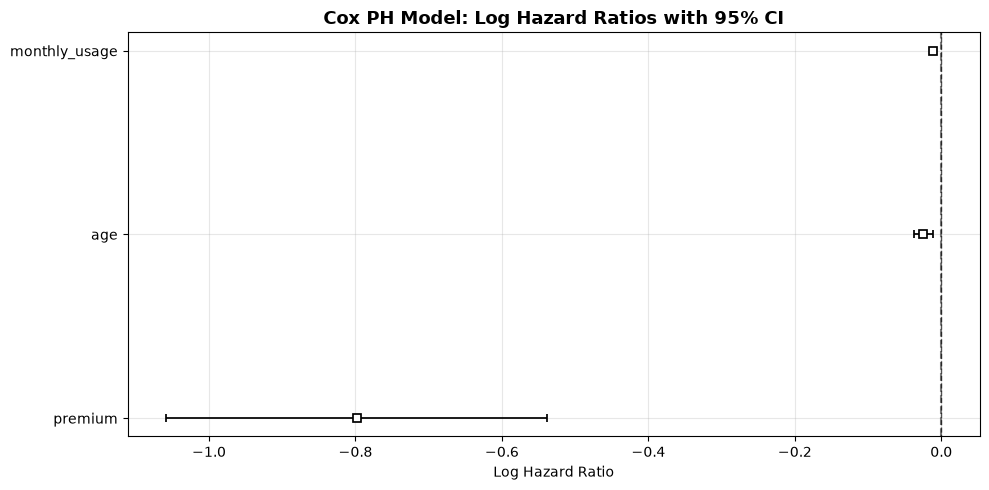

Note: Negative log HR means protective (HR < 1 means lower churn hazard).


In [10]:
# Plot Cox model hazard ratios with confidence intervals
fig, ax = plt.subplots(figsize=(10, 5))
cph.plot(ax=ax)
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set_title('Cox PH Model: Log Hazard Ratios with 95% CI', fontsize=13, fontweight='bold')
ax.set_xlabel('Log Hazard Ratio')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('Note: Negative log HR means protective (HR < 1 means lower churn hazard).')

## 7. Weibull AFT (Accelerated Failure Time) Model

The **Accelerated Failure Time (AFT)** model is an alternative to Cox PH. Instead of modeling how features affect the hazard rate, it models how features **accelerate or decelerate** the time to event.

The AFT model says:
$$\log(T) = \beta_0 + \beta_1 X_1 + \ldots + \beta_p X_p + \sigma \epsilon$$

where T is the time to event and epsilon follows a specified distribution. With the Weibull distribution for T, this is the **Weibull AFT model**.

**Interpretation**: coefficients represent log-time ratios. exp(beta_j) > 1 means the feature extends survival time; exp(beta_j) < 1 means it shortens survival.

**When to prefer AFT over Cox PH**:
- When proportional hazards assumption is violated
- When you need explicit time predictions
- When mechanistic interpretation in terms of time acceleration is more natural

In [11]:
# Fit Weibull AFT model
waft = WeibullAFTFitter()
waft.fit(
    df_cox,
    duration_col='duration',
    event_col='churned',
    formula='premium + age + monthly_usage'
)

print('Weibull AFT Model Summary:')
print('=' * 60)
waft.print_summary()
print()
print(f'Weibull AFT Concordance Index: {waft.concordance_index_:.4f}')

Weibull AFT Model Summary:


<lifelines.WeibullAFTFitter: fitted with 500 total observations, 241 right-censored observations>
             duration col = 'duration'
                event col = 'churned'
   number of observations = 500
number of events observed = 259
           log-likelihood = -1102.89
         time fit was run = 2026-06-29 07:14:54 UTC

---
                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                      
lambda_ Intercept      2.21      9.10      0.17            1.88            2.54                6.54               12.66
        premium        0.54      1.72      0.09            0.36            0.72                1.44                2.06
        age            0.02      1.02      0.00            0.01            0.03                1.01                1.03
        monthly_usage  0.01      1.01      0.00            0.01            0.01                1.01                1.01
rho_    Intercept      0.39      1.47      0.05            0.28            0.49                1.33                1.64

                       cmp to     z      p  -log2(p)
param   covariate                                   
lambda_ Intercept        0.00 13.11 <0.005    127.98
        premium          0.00  5.93 <0.005     28.32
        age              0.00  3.70 <0.005     12.16
        monthly_usage    0.00  5.90 <0.005     28.06
rho_    Intercept        0.00  7.22 <0.005     40.85
---
Concordance = 0.66
AIC = 2215.78
log-likelihood ratio test = 91.69 on 3 df
-log2(p) of ll-ratio test = 63.19


Weibull AFT Concordance Index: 0.6623


## 8. Predicting Survival for New Customers

One key application is predicting the survival probability for new customers at specific time horizons -- useful for customer lifetime value (CLV) calculations and early intervention.

In [12]:
# Define new customer profiles
new_customers = pd.DataFrame({
    'premium':       [0, 1, 0, 1],
    'age':           [25, 25, 45, 45],
    'monthly_usage': [20, 20, 80, 80]
})
new_customers.index = [
    'Young Basic Low-Usage',
    'Young Premium Low-Usage',
    'Mature Basic High-Usage',
    'Mature Premium High-Usage'
]

# Predict survival at 6, 12, 24 months
time_points = [6, 12, 24]
predictions = cph.predict_survival_function(new_customers, times=time_points)

print('Predicted Survival Probabilities (Cox PH Model):')
print(f'{"Customer Profile":<30} {"6mo":>8} {"12mo":>8} {"24mo":>8}')
print('-' * 56)
for col in predictions.columns:
    vals = predictions[col].values
    print(f'{col:<30} {vals[0]:>8.3f} {vals[1]:>8.3f} {vals[2]:>8.3f}')

Predicted Survival Probabilities (Cox PH Model):
Customer Profile                    6mo     12mo     24mo
--------------------------------------------------------
Young Basic Low-Usage             0.775    0.535    0.174
Young Premium Low-Usage           0.892    0.754    0.455
Mature Basic High-Usage           0.926    0.827    0.588
Mature Premium High-Usage         0.966    0.918    0.787


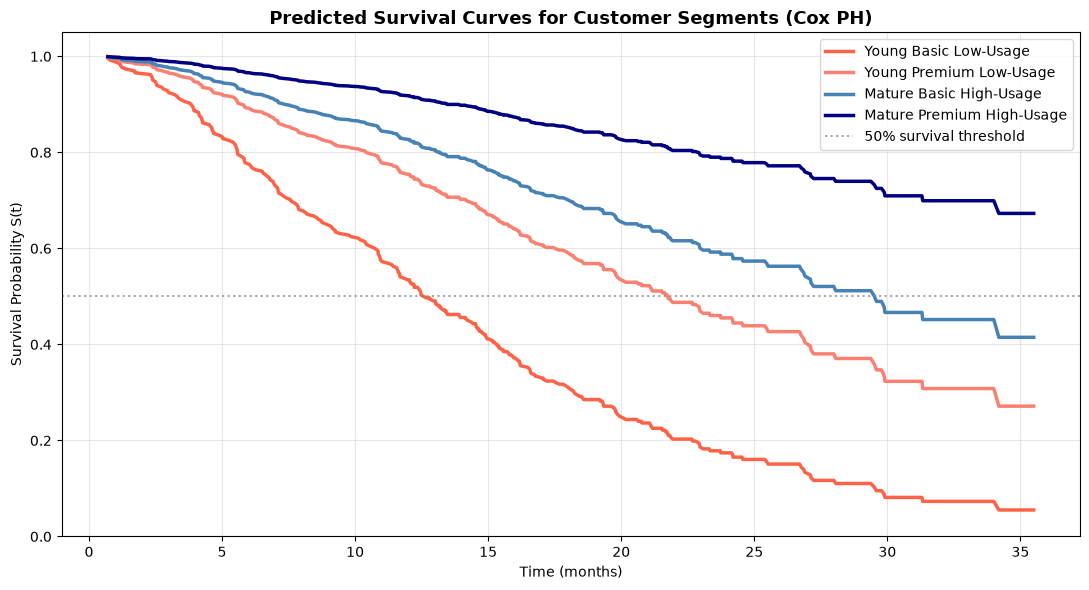

In [13]:
# Plot survival curves for new customer profiles
fig, ax = plt.subplots(figsize=(11, 6))

colors = ['tomato', 'salmon', 'steelblue', 'navy']
survival_curves = cph.predict_survival_function(new_customers)

for i, (col, color) in enumerate(zip(survival_curves.columns, colors)):
    ax.plot(survival_curves.index, survival_curves[col],
            color=color, linewidth=2.5, label=col)

ax.axhline(0.5, color='gray', linestyle=':', alpha=0.7, label='50% survival threshold')
ax.set_title('Predicted Survival Curves for Customer Segments (Cox PH)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time (months)')
ax.set_ylabel('Survival Probability S(t)')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. The C-Index: Evaluation Metric for Survival Models

The **Concordance Index (C-index)**, also called **Harrell's C**, is the standard metric for survival model discrimination.

**Definition**: Given all possible pairs of subjects where one experienced the event before the other (and the comparison is valid -- i.e., neither is censored before the event in the pair), the C-index is the proportion of pairs where the model correctly ranks the higher-risk subject as having the shorter survival time.

$$C = \frac{\text{concordant pairs}}{\text{concordant pairs + discordant pairs}}$$

**Comparison with AUC-ROC**:
- AUC measures discrimination for binary classification at a single threshold
- C-index measures ranking ability across the entire risk spectrum, handling censoring
- Both range from 0.5 (random) to 1.0 (perfect); they are equivalent when there is no censoring

In [14]:
# Compute C-index manually to understand the concept
def compute_c_index_simple(durations, events, risk_scores):
    """
    Simple C-index computation (without censoring adjustment for illustration).
    Higher risk_score should correspond to shorter duration.
    """
    n = len(durations)
    concordant = 0
    discordant = 0
    tied = 0
    valid_pairs = 0

    for i in range(n):
        for j in range(i + 1, n):
            # Only consider pair if at least one had the event
            # and we can determine ordering
            if events[i] == 0 and events[j] == 0:
                continue  # both censored: uninformative
            if events[i] == 0 and durations[i] <= durations[j]:
                continue  # i censored before j's event: uninformative
            if events[j] == 0 and durations[j] <= durations[i]:
                continue  # j censored before i's event: uninformative

            valid_pairs += 1

            # Determine who failed first
            if durations[i] < durations[j]:
                # i failed first; higher risk score for i is concordant
                if risk_scores[i] > risk_scores[j]:
                    concordant += 1
                elif risk_scores[i] < risk_scores[j]:
                    discordant += 1
                else:
                    tied += 1
            elif durations[j] < durations[i]:
                if risk_scores[j] > risk_scores[i]:
                    concordant += 1
                elif risk_scores[j] < risk_scores[i]:
                    discordant += 1
                else:
                    tied += 1

    if valid_pairs == 0:
        return 0.5
    return (concordant + 0.5 * tied) / valid_pairs

# Use a sample for speed
sample = df_cox.sample(200, random_state=42)
# Risk score from Cox: higher partial hazard = higher churn risk
risk = cph.predict_partial_hazard(sample).values

c_manual = compute_c_index_simple(
    sample['duration'].values,
    sample['churned'].values,
    risk
)
print(f'Manual C-index (sample of 200):  {c_manual:.4f}')
print(f'lifelines C-index (full data):   {cph.concordance_index_:.4f}')
print()
print('Note: The manual calculation uses a simplified version.')
print('lifelines uses the full Harrell formula with proper censoring handling.')

Manual C-index (sample of 200):  0.6722
lifelines C-index (full data):   0.6623

Note: The manual calculation uses a simplified version.
lifelines uses the full Harrell formula with proper censoring handling.


## 10. Use Cases: When Survival Analysis Is the Right Tool

Survival analysis should be your default when you have **time-to-event data with censoring**. Here are the key domains:

In [15]:
use_cases = {
    'Customer Churn': {
        'Event': 'Customer cancels subscription',
        'Censoring': 'Customer still active at data pull',
        'Why not regression': 'Cannot regress on duration when many are still alive',
        'Business value': 'Prioritize at-risk customers for retention offers'
    },
    'Medical/Clinical': {
        'Event': 'Patient death, disease recurrence, or recovery',
        'Censoring': 'Patient lost to follow-up or study ends',
        'Why not regression': 'Patients have different follow-up lengths',
        'Business value': 'Compare treatment arms, predict patient prognosis'
    },
    'Equipment/Manufacturing': {
        'Event': 'Machine failure or component breakdown',
        'Censoring': 'Machine still running or replaced for other reasons',
        'Why not regression': 'Some machines never fail in the observation window',
        'Business value': 'Optimize preventive maintenance schedules'
    },
    'Credit/Finance': {
        'Event': 'Loan default or early repayment',
        'Censoring': 'Loan still performing or transferred',
        'Why not regression': 'Many loans are outstanding when data is collected',
        'Business value': 'Price risk, estimate expected loss at different time horizons'
    },
    'Human Resources': {
        'Event': 'Employee resignation',
        'Censoring': 'Employee still at the company',
        'Why not regression': 'Tenure is only known for past employees',
        'Business value': 'Identify flight risk, plan succession'
    }
}

for domain, info in use_cases.items():
    print(f'--- {domain} ---')
    for key, val in info.items():
        print(f'  {key}: {val}')
    print()

--- Customer Churn ---
  Event: Customer cancels subscription
  Censoring: Customer still active at data pull
  Why not regression: Cannot regress on duration when many are still alive
  Business value: Prioritize at-risk customers for retention offers

--- Medical/Clinical ---
  Event: Patient death, disease recurrence, or recovery
  Censoring: Patient lost to follow-up or study ends
  Why not regression: Patients have different follow-up lengths
  Business value: Compare treatment arms, predict patient prognosis

--- Equipment/Manufacturing ---
  Event: Machine failure or component breakdown
  Censoring: Machine still running or replaced for other reasons
  Why not regression: Some machines never fail in the observation window
  Business value: Optimize preventive maintenance schedules

--- Credit/Finance ---
  Event: Loan default or early repayment
  Censoring: Loan still performing or transferred
  Why not regression: Many loans are outstanding when data is collected
  Business val

## 11. Why Not Just Use Logistic Regression or Linear Regression?

A natural question is: why not just use simpler approaches?

In [16]:
comparison = pd.DataFrame([
    {
        'Approach': 'Logistic Regression (will churn? Y/N)',
        'Handles Censoring': 'No -- treats censored as non-events',
        'Time Info Used': 'No',
        'Issue': 'Biased: censored customers incorrectly labeled as not churned'
    },
    {
        'Approach': 'Linear Regression (predict time to churn)',
        'Handles Censoring': 'No -- must drop or impute censored',
        'Time Info Used': 'Yes',
        'Issue': 'Biased: dropping censored keeps only short-tenure churners'
    },
    {
        'Approach': 'Survival Analysis (Cox PH / KM)',
        'Handles Censoring': 'Yes -- uses all data correctly',
        'Time Info Used': 'Yes',
        'Issue': 'None -- designed for this exact problem'
    }
])

print('Approach Comparison:')
print(comparison.to_string(index=False))

Approach Comparison:
                                 Approach                   Handles Censoring Time Info Used                                                         Issue
    Logistic Regression (will churn? Y/N) No -- treats censored as non-events             No Biased: censored customers incorrectly labeled as not churned
Linear Regression (predict time to churn)  No -- must drop or impute censored            Yes    Biased: dropping censored keeps only short-tenure churners
          Survival Analysis (Cox PH / KM)      Yes -- uses all data correctly            Yes                       None -- designed for this exact problem


## 12. Key Takeaways

This notebook demonstrated the core tools of survival analysis. Here is what to remember:

| Concept | What It Does | When to Use |
|---------|-------------|-------------|
| **Kaplan-Meier** | Non-parametric survival curve | Exploratory analysis, comparing groups visually |
| **Log-Rank Test** | Hypothesis test for group differences | Checking if two or more groups have different survival |
| **Cox PH Model** | Semi-parametric hazard regression | When you want covariate effects; default choice |
| **Weibull AFT** | Parametric time-acceleration model | When proportional hazards fails; need explicit time predictions |
| **C-index** | Ranking discrimination metric | Evaluating any survival model (analogous to AUC) |

**The censoring insight**: Never discard censored observations. A customer who has not churned in 30 months tells you something very valuable -- that they survived at least 30 months. Survival analysis uses this information correctly.

**Practical tips**:
1. Always start with Kaplan-Meier plots -- they reveal the shape of your survival data immediately
2. Use the log-rank test to check if stratification variables matter before building Cox models
3. Verify the proportional hazards assumption before trusting Cox PH results (lifelines has `cph.check_assumptions()`)
4. The C-index is your primary evaluation metric; anything above 0.7 is meaningful for noisy real-world data
5. For production churn models, combine survival analysis with gradient boosting (pycox library) for higher accuracy